<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/regularised_deep_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.2624 - val_loss: 0.1837
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 0.1649 - val_loss: 0.1528
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.1487 - val_loss: 0.1419
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 0.1405 - val_loss: 0.1386
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 0.1358 - val_loss: 0.1327
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 0.1324 - val_loss: 0.1300
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.1302 - val_loss: 0.1277
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.1284 - val_loss: 0.1267
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 0.1271 - val_loss: 0.1270
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 0.1258 - val_loss: 0.1240
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 0.125

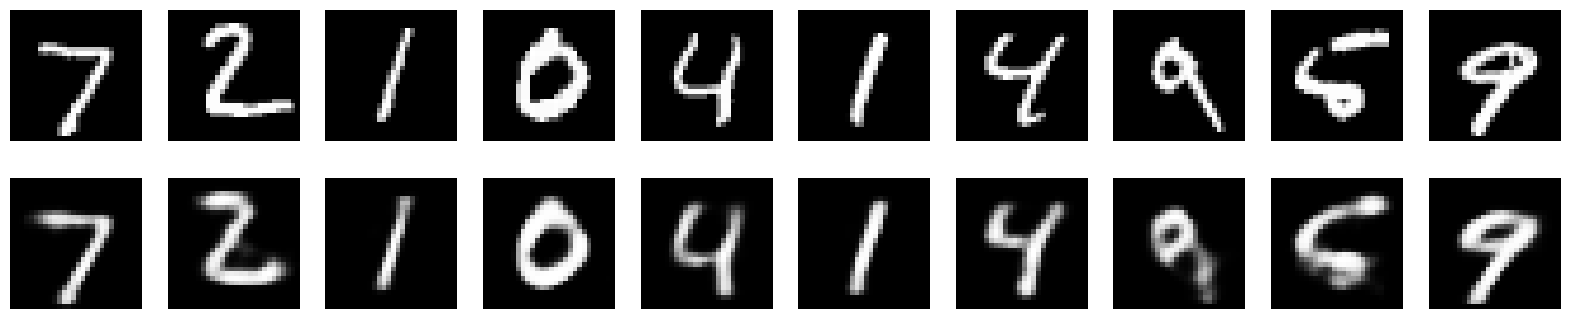

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

# Load data
(x_train,_),(x_test,_) = tf.keras.datasets.mnist.load_data()

# Normalize and flatten
x_train = x_train.reshape(-1,784)/255.0
x_test = x_test.reshape(-1,784)/255.0

reg = regularizers.l2(1e-4)

# Encoder
inp = layers.Input(shape=(784,))
x = layers.Dense(512,activation='relu',kernel_regularizer=reg)(inp)
x = layers.Dense(256,activation='relu',kernel_regularizer=reg)(x)
encoded = layers.Dense(128,activation='relu',kernel_regularizer=reg)(x)

# Decoder
x = layers.Dense(256,activation='relu',kernel_regularizer=reg)(encoded)
x = layers.Dense(512,activation='relu',kernel_regularizer=reg)(x)
out = layers.Dense(784,activation='sigmoid')(x)

# Model
autoencoder = tf.keras.Model(inp,out)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

# Train
autoencoder.fit(x_train,x_train,epochs=20,batch_size=256,validation_data=(x_test,x_test))

# Reconstruction
decoded = autoencoder.predict(x_test)

# Plot
n=10
plt.figure(figsize=(20,4))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray'); plt.axis('off')

    plt.subplot(2,n,i+n+1)
    plt.imshow(decoded[i].reshape(28,28),cmap='gray'); plt.axis('off')

plt.show()